## Análisis de datos II - Clase 7
---

### Selección de features con métodos embebidos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import roc_auc_score

---
### 1. Datos

Dataset a utilizar: Breast Cancer Wisconsin (incluido en scikit-learn). Contiene información de 569 tumores y 30 features calculadas a partir de imágenes de biopsias. El objetivo es predecir si el tumor es maligno o benigno.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = 1 - data.target # en el dataset original 0 = maligno,  lo invierto para que 1 = maligno

print(f"Observaciones: {X.shape[0]} \nFeatures: {X.shape[1]}")
print(f"Malignos: {y.mean():.0%} \nBenignos: {1 - y.mean():.0%}")
X.head()

Observaciones: 569 
Features: 30
Malignos: 37% 
Benignos: 63%


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Las 30 features son 10 medidas del núcleo celular (radio, textura, perímetro, área, suavidad, etc.), cada una calculada de tres formas: media, error estándar y peor valor (worst).

Muchas variables están muy correlacionadas entre sí. Por ejemplo, el radio, el perímetro y el área miden prácticamente lo mismo.

In [3]:
X[["mean radius", "mean perimeter", "mean area", "worst radius", "worst perimeter", "worst area"]].corr()

,mean radius,mean perimeter,mean area,worst radius,worst perimeter,worst area
mean radius,1.000000,0.997855,0.987357,0.969539,0.965137,0.941082
mean perimeter,0.997855,1.000000,0.986507,0.969476,0.970387,0.941550
mean area,0.987357,0.986507,1.000000,0.962746,0.959120,0.959213
worst radius,0.969539,0.969476,0.962746,1.000000,0.993708,0.984015
worst perimeter,0.965137,0.970387,0.959120,0.993708,1.000000,0.977578
worst area,0.941082,0.941550,0.959213,0.984015,0.977578,1.000000


---
### 2. Split del dataset

In [4]:
# Separo 20% para test
X_resto, X_test, y_resto, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Separo 25% del resto para val
X_train, X_val, y_train, y_val = train_test_split(
    X_resto, y_resto, test_size=0.25, random_state=42, stratify=y_resto)

print(f"Train: {X_train.shape} - Val: {X_val.shape} -  Test: {X_test.shape}")

Train: (341, 30) - Val: (114, 30) -  Test: (114, 30)


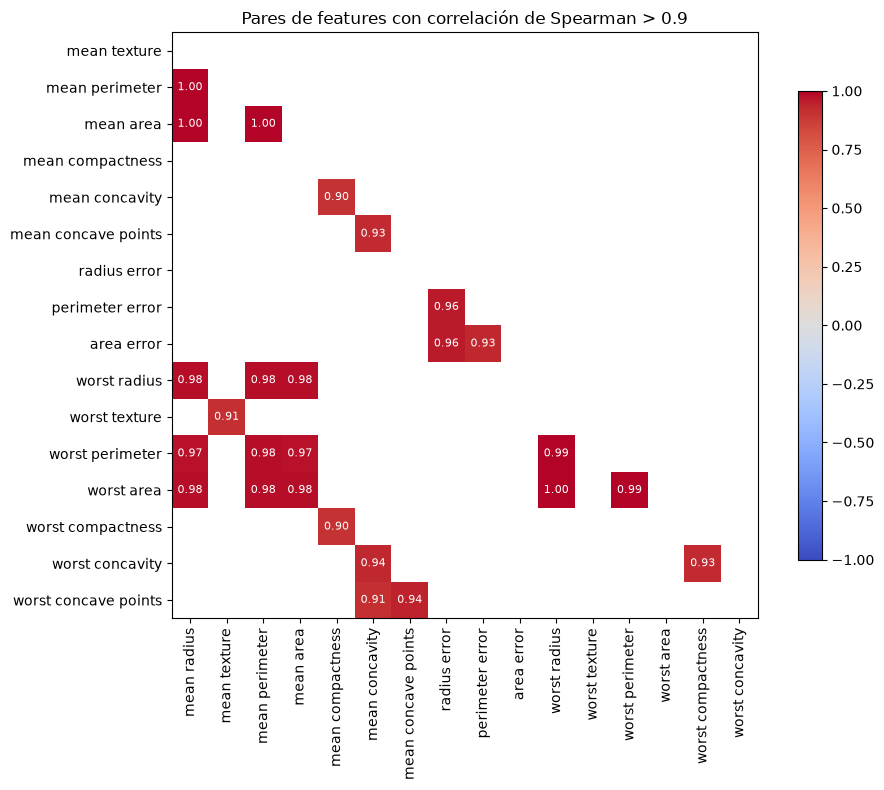

Features con al menos un par redundante: 17 de 30


In [5]:
# Correlación de Spearman entre features (solo con train)
corr = X_train.corr(method="spearman")
umbral = 0.9

# Nos quedamos solo con las features que tienen al menos un par por encima del umbral
fuera_diagonal = corr.mask(np.eye(len(corr), dtype=bool))
con_pares = fuera_diagonal.abs().max() > umbral
corr_filtrada = corr.loc[con_pares, con_pares]

# Ocultamos las celdas que no superan el umbral y la mitad superior (incluida la diagonal)
mitad_inferior = np.tril(np.ones(corr_filtrada.shape, dtype=bool), k=-1)
corr_filtrada = corr_filtrada.where((corr_filtrada.abs() > umbral) & mitad_inferior)

# La primera fila y la última columna quedan vacías: las sacamos
corr_filtrada = corr_filtrada.iloc[1:, :-1]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_filtrada, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(corr_filtrada.shape[1]), corr_filtrada.columns, rotation=90, fontsize=10)
ax.set_yticks(range(corr_filtrada.shape[0]), corr_filtrada.index, fontsize=10)
for i in range(corr_filtrada.shape[0]):
    for j in range(corr_filtrada.shape[1]):
        valor = corr_filtrada.iloc[i, j]
        if pd.notna(valor):
            ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8, color="white")
ax.set_title(f"Pares de features con correlación de Spearman > {umbral}")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"Features con al menos un par redundante: {con_pares.sum()} de {len(corr)}")

Grupos de features muy correlacionadas (Spearman mayor a 0,9):

* Tamaño: mean radius, mean perimeter, mean area, worst radius, worst perimeter, worst area.
* Error del tamaño: radius error, perimeter error, area error.
* Forma: mean compactness, mean concavity, mean concave points, worst compactness, worst concavity, worst concave points.
* Textura: mean texture, worst texture.

---
### 3. Lasso (penalidad L1)

En clasificación, el equivalente a Lasso es una regresión logística con penalidad L1.

El parámetro C es la inversa de la penalidad (α): cuanto más chico C, más fuerte la penalidad y más coeficientes quedan en 0.

In [6]:
# Valores de C=1/α para regularización L1 
valores_C = [0.01, 0.03, 0.05, 0.1, 0.3, 1, 3, 10]

filas = []
for C in valores_C:
    modelo = make_pipeline(StandardScaler(),
                           LogisticRegression(C=C, solver="liblinear", random_state=42, l1_ratio=1,))
    modelo.fit(X_train, y_train)
    n_features = (modelo[-1].coef_ != 0).sum()
    auc = roc_auc_score(y_val, modelo.predict_proba(X_val)[:, 1])
    filas.append({"C": C, "Features conservadas": n_features,
                  "ROC AUC (validación)": round(auc, 2)})

tabla = pd.DataFrame(filas).set_index("C")
tabla

,Features conservadas,ROC AUC (validación)
C,,
0.01,2,0.97
0.03,4,0.98
0.05,5,0.98
0.10,6,0.98
0.30,8,0.99
1.00,14,0.99
3.00,15,1.00
10.00,20,1.00


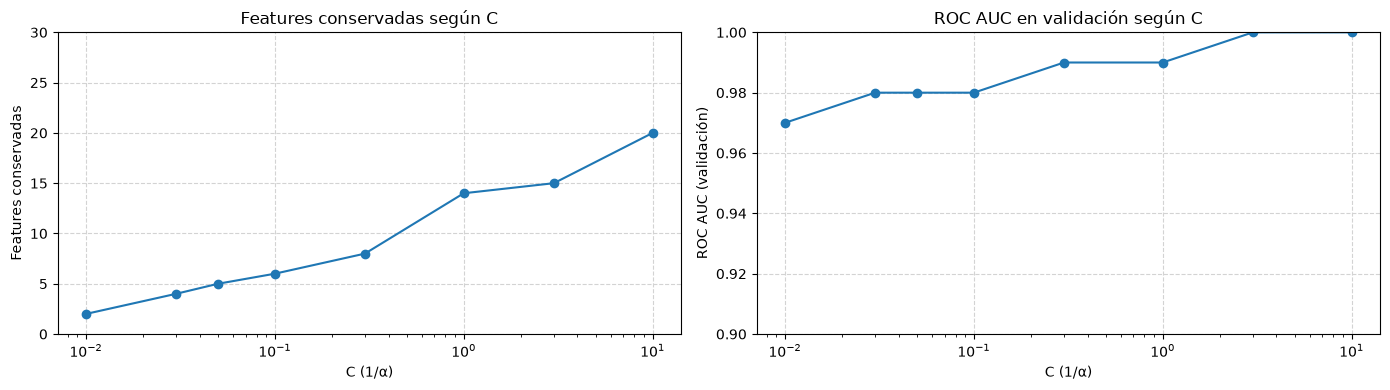

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

# Gráfico 1: cantidad de features
axes[0].plot(tabla.index, tabla["Features conservadas"], "o-")
axes[0].set_title("Features conservadas según C")
axes[0].set_ylabel("Features conservadas")
axes[0].set_ylim(0, 30)

# Gráfico 2: rendimiento
axes[1].plot(tabla.index, tabla["ROC AUC (validación)"], "o-")
axes[1].set_title("ROC AUC en validación según C")
axes[1].set_ylabel("ROC AUC (validación)")
axes[1].set_ylim(0.9, 1)

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("C (1/α)")
    ax.grid(ls="--", color="lightgray")

plt.tight_layout()
plt.show()

Con C = 0,03 el modelo conserva muy pocas features y el ROC AUC es prácticamente el mismo que con las 30 (0,98 vs 1)

Selección: como regla general, se suele elegir el C que balancea rendimiento con cantidad de features. En este caso seleccionamos el modelo con C=0,03

#### Vemos qué features elige el método con C=0.03 y qué resultados da en test:

Features conservadas: 4 de 30



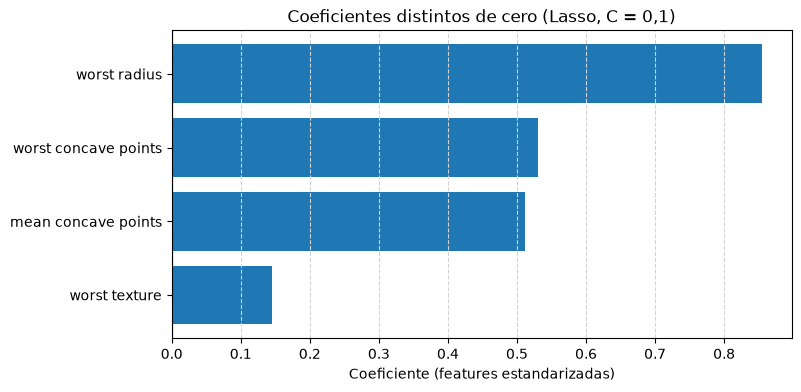

In [8]:
lasso = make_pipeline(StandardScaler(),
                      LogisticRegression(C=0.03, solver="liblinear", random_state=42,l1_ratio=1))
lasso.fit(X_train, y_train)

coefs = pd.Series(lasso[-1].coef_[0], index=X.columns)
elegidas = coefs[coefs != 0].sort_values(key=abs)

print(f"Features conservadas: {len(elegidas)} de {len(coefs)}\n")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(elegidas.index, elegidas.values)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Coeficientes distintos de cero (Lasso, C = 0,1)")
ax.set_xlabel("Coeficiente (features estandarizadas)")
ax.grid(axis="x", ls="--", color="lightgray")
plt.show()

In [9]:
# Evaluación final en test con el modelo elegido (C=0.03)
auc_test = roc_auc_score(y_test, lasso.predict_proba(X_test)[:, 1])

print(f"Modelo final: {len(elegidas)} features y C = 0,03")
print(f"ROC AUC en test: {auc_test:.2f}")

Modelo final: 4 features y C = 0,03
ROC AUC en test: 1.00


Había 9 features que miden el tamaño del núcleo (radio, perímetro y área, cada una en sus 3 versiones). Lasso conservó solo 3 (worst radius, worst perimeter y radius error) y descartó las otras 6 que son redundantes.

---
### 4. Importancia de features en árboles

Ahora vamos a analizar otro método, importancia de features. Vamos a utilizar un Random Forest.

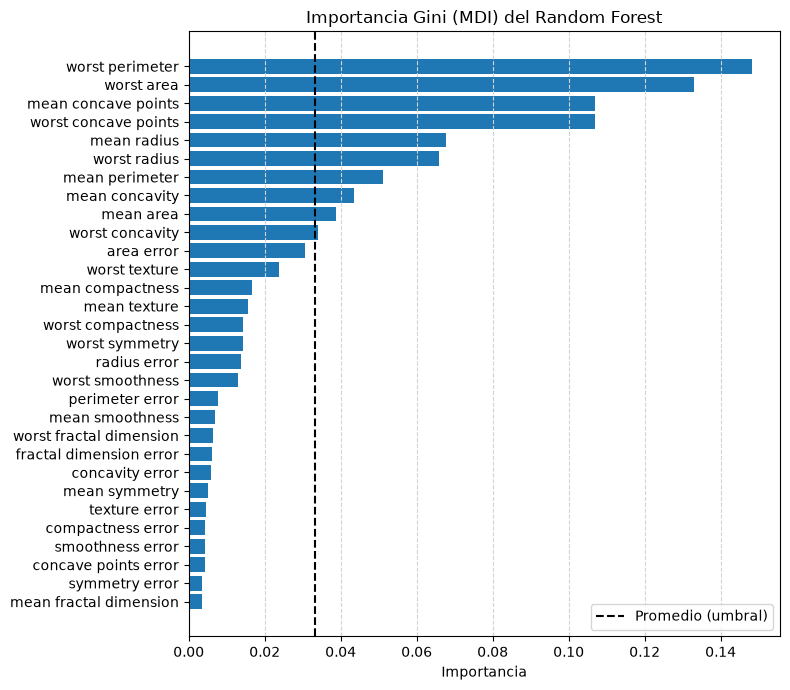

Features conservadas: 10 de 30
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points'] 

ROC AUC en validación: 0.99
ROC AUC en test: 1.00


In [10]:
# 1. Importancia Gini (MDI): el Random Forest la calcula mientras entrena
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importancia = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importancia.index, importancia.values)
ax.axvline(importancia.mean(), color="black", ls="--", label="Promedio (umbral)")
ax.set_title("Importancia Gini (MDI) del Random Forest")
ax.set_xlabel("Importancia")
ax.legend()
ax.grid(axis="x", ls="--", color="lightgray")
plt.tight_layout()
plt.show()

# 2. Selección: nos quedamos con las features con importancia mayor al promedio
modelo_rf = make_pipeline(
    SelectFromModel(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                    threshold="mean"),
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
)
modelo_rf.fit(X_train, y_train)

seleccionadas = X.columns[modelo_rf[0].get_support()]
print(f"Features conservadas: {len(seleccionadas)} de {X.shape[1]}")
print(list(seleccionadas), "\n")

# 3. Evaluación: validación y, al final, test (una sola vez)
auc_val = roc_auc_score(y_val, modelo_rf.predict_proba(X_val)[:, 1])


auc_test = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:, 1])
print(f"ROC AUC en validación: {auc_val:.2f}")
print(f"ROC AUC en test: {auc_test:.2f}")

Vemos que la importancia se reparte entre features redundantes.


Aplicamos un filtro antes, para eliminar la redundancia y lo volvemos a ejecutar:

Filtro de correlación: quedan 19 de 30 features
Descartadas: ['mean perimeter', 'mean area', 'mean concavity', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst compactness', 'worst concave points'] 



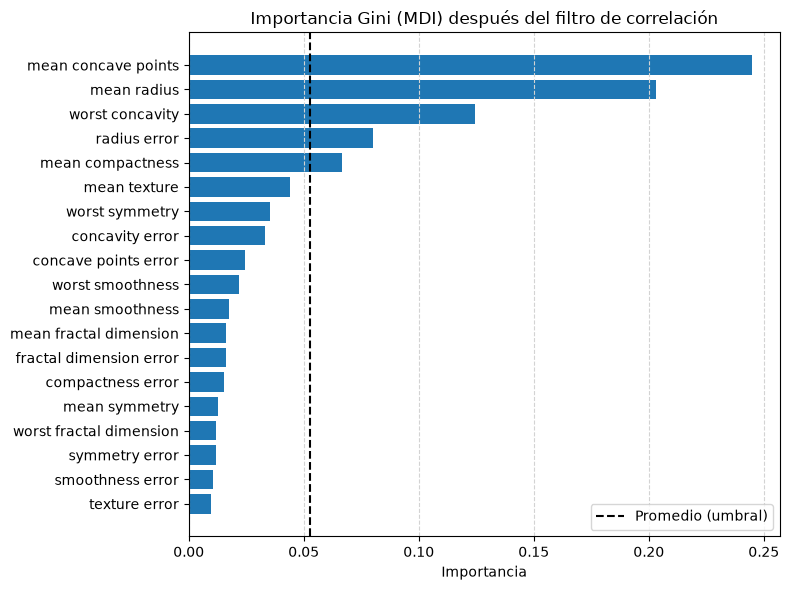

Features finales: 5
['mean radius', 'mean compactness', 'mean concave points', 'radius error', 'worst concavity'] 

ROC AUC en validación: 0.98
ROC AUC en test: 0.99


In [11]:
# Filtro de correlación (solo con train)
# Recorremos las features en orden: si una tiene correlación > umbral con alguna
# que ya conservamos, la descartamos.
umbral = 0.9
corr = X_train.corr(method="spearman").abs()

conservadas = []
for feature in corr.columns:
    if all(corr.loc[feature, otra] <= umbral for otra in conservadas):
        conservadas.append(feature)

descartadas = [f for f in X.columns if f not in conservadas]
print(f"Filtro de correlación: quedan {len(conservadas)} de {X.shape[1]} features")
print("Descartadas:", descartadas, "\n")

# Importancia Gini con las features que pasaron el filtro
rf_filtrado = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_filtrado.fit(X_train[conservadas], y_train)

importancia_filtrada = pd.Series(rf_filtrado.feature_importances_, index=conservadas).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importancia_filtrada.index, importancia_filtrada.values)
ax.axvline(importancia_filtrada.mean(), color="black", ls="--", label="Promedio (umbral)")
ax.set_title("Importancia Gini (MDI) después del filtro de correlación")
ax.set_xlabel("Importancia")
ax.legend()
ax.grid(axis="x", ls="--", color="lightgray")
plt.tight_layout()
plt.show()

# Selección por importancia (tomo todas que sean mayor al promedio) y evaluación
modelo_filtrado = make_pipeline(
    SelectFromModel(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
                    threshold="mean"),
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
)
modelo_filtrado.fit(X_train[conservadas], y_train)

soporte = modelo_filtrado[0].get_support()
seleccionadas_filtro = [f for f, elegida in zip(conservadas, soporte) if elegida]
print(f"Features finales: {len(seleccionadas_filtro)}")
print(seleccionadas_filtro, "\n")

auc_val = roc_auc_score(y_val, modelo_filtrado.predict_proba(X_val[conservadas])[:, 1])
auc_test = roc_auc_score(y_test, modelo_filtrado.predict_proba(X_test[conservadas])[:, 1])
print(f"ROC AUC en validación: {auc_val:.2f}")
print(f"ROC AUC en test: {auc_test:.2f}")

El filtro de correlación saca 11 features (quedan 19). Por ejemplo, de las 6 features de tamaño queda solo mean radius.
La selección por importancia se queda con 5 de esas 19.

---
Observaciones finales:

Importancia de features (árboles):
- Sirve para un primer ranking, pero con features redundantes la importancia se reparte entre ellas y hay que interpretarla con cuidado.
- Conviene aplicar antes un filtro simple (por ejemplo de correlación) para eliminar la redundancia antes de entrenar el modelo.

Regularización L1:
- Es un modelo lineal. Si la relación de una feature con la target no es lineal, puede descartarla aunque sea útil.
- Ante features redundantes, se queda con una de cada grupo y lleva los coeficientes de las demás a cero. Por eso no necesita un filtro de correlación previo.
- La feature que conserva de cada grupo es casi arbitraria (con otros datos podría elegir otra). Que una feature quede en cero no significa que no esté relacionada con la target.